In [6]:
import sys
import os

sys.path.insert(1, "../")

# current_dir = os.path.dirname(os.path.abspath(__file__))

# parent_dir = os.path.dirname(current_dir)

# sys.path.insert(1, parent_dir)
import gymnasium as gym
import numpy as np
import argparse
import time
from utils.wrapper import JupyterRender
from collections import defaultdict

#initialize policy_array randomly
#initialize Q(s, a) randomly 
#initialize Returns to an empty defaultdict
#loop in range episode count
#simulate policym, fill trajectory 
#loop in reversed(trajectory) get returns
#average returns
#policy improvement

class OnPolicyMonteCarlo:
    def __init__ (self, env, type, episode_count, step_size, gamma, epsilon):
        self.epsilon = epsilon
        self.step_size = step_size
        self.gamma = gamma
        self.env = env
        self.type = type
        
        self.episode_count = episode_count
        self.obs_dim = self.env.observation_space.n
        self.act_dim = self.env.action_space.n
        

        self.returns = defaultdict(list)
        self.Q = np.zeros((self.obs_dim, self.act_dim), dtype = np.float32)
        self.policy_array = np.random.choice(self.act_dim, size=self.obs_dim)
        self.loop()
        
    def __call__(self):
        self.env.render(q = self.Q, policy=self.policy_array)
        time.sleep(0.4)
        return self.policy_array


    def loop(self):
        for i in range(self.episode_count):
            self.episode = i
            
            self.simulate_policy()
            if self.type == "every_visit":
                    self.return_sampling_every_visit()
            elif self.type == "first_visit":
                    self.return_sampling_first_visit()
            
           



    def return_sampling_every_visit(self):
        G = 0
        for o, a, r in reversed(self.trajectory):
            G = self.gamma * G + r
            self.returns[(o,a)].append(G)
            self.Q[o, a] = np.mean(self.returns[(o, a)])
            self.policy_array[o] = np.argmax(self.Q[o])
            
      

    def return_sampling_first_visit(self):
        G = 0
        visited = set()
        for o, a, r in reversed(self.trajectory):
            G = self.gamma * G + r
            if o not in visited:
                visited.add(o)
                self.returns[(o,a)].append(G)
                self.Q[o, a] = np.mean(self.returns[(o, a)])
                self.policy_array[o] = np.argmax(self.Q[o])
        

    def simulate_policy(self):
        o, _ = self.env.reset()
        self.trajectory = []
        done = False
        local_step = 0
        while not done:
            self.env.render(title=f"Episode {self.episode} / step {local_step}", q=self.Q, policy=self.policy_array)
            
            a = self.epsilon_greedy_action(o)
            o2, r, done, _, _ = self.env.step(a)
            
            
            if r == 0:
                
                r = -0.1
                    
                # give penalty for falling into the hole
            if done and o2 != 15:
                r = -20

            if local_step == 40:
                done = True #prevent infinite episode
                r = -1

            if o == o2: # prevent meaningless actions
                r = -1
            
            if o2 == 15:
                r = 20

            local_step += 1 
            

            self.trajectory.append((o, a, r))
            o = o2

   
    
    def epsilon_greedy_action(self, state):
       
        if np.random.random() < self.epsilon:
            return self.env.action_space.sample()  
        else:
            return self.policy_array[state]
        
        

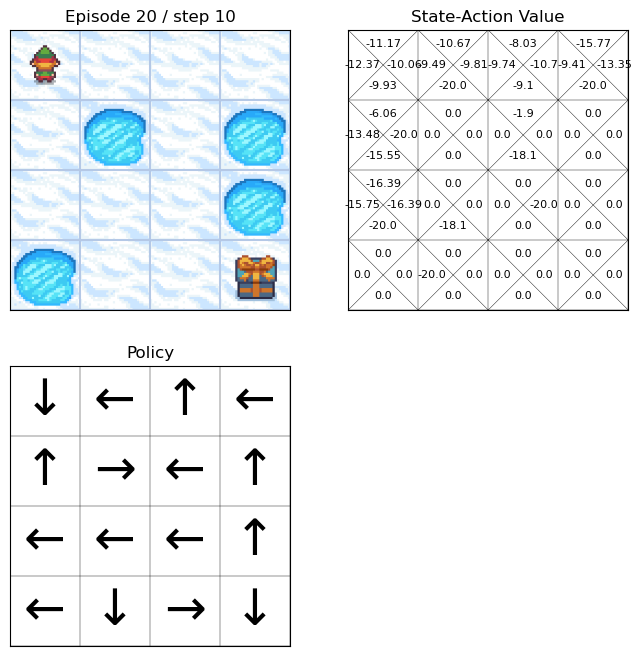

In [9]:
env = gym.make(
        'FrozenLake-v1',
        desc= None,
        map_name = "4x4",
        is_slippery=False,
        render_mode = "rgb_array"
        )
    
env = JupyterRender(env)
algorithm = OnPolicyMonteCarlo(env, type = "every_visit", episode_count = 200, step_size = 0.01, gamma = 0.9, epsilon = 0.4)

policy_array = algorithm()

success_count = 0
for eisode in range(1000):
    state = env.reset()[0]
    done = False
    while not done:
        action = algorithm.policy_array[state]
        print(action)
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
    if reward == 1:
        success_count += 1

    print(f"Success rate: {success_count}/1000 = {success_count/10}%")
env.close()

Off Policy Monte Carlo:


In [1]:
import sys
import os

sys.path.insert(1, "../")

# current_dir = os.path.dirname(os.path.abspath(__file__))

# parent_dir = os.path.dirname(current_dir)

# sys.path.insert(1, parent_dir)
import gymnasium as gym
import numpy as np
import argparse
import time
from utils.wrapper import JupyterRender
from collections import defaultdict

In [ ]:


#initialize policy_array randomly
#initialize Q(s, a) randomly 
#initialize Returns to an empty defaultdict
#loop in range episode count
#simulate policym, fill trajectory 
#loop in reversed(trajectory) get returns
#average returns
#policy improvement


In [ ]:
class OffPolicyMonteCarlo:
    def __init__(self):
        pass
    